<a href="https://colab.research.google.com/github/ednavivianasegura/Curso_ML_Python/blob/main/Modulo3_RedesNeuronales/redes_convolucionales_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autores:** Edna Viviana Segura Alvarado - Hans Mauricio Carrillo Hernández

**Institución:** Universidad de la Rioja

**Fecha:** Junio/2025

**Clasificación de Imágenes con Redes Neuronales Convolucionales**

Las redes neuronales convolucionales son conocidas habitualmente por sus siglas en inglés, CNNs (Convolutional Neural Networks).


In [2]:
# @title
# Celda 1: Instalar gdown y definir variables
!pip install gdown -q
FILE_ID       = '1JQ9OgAMs_AjgtuwI6vujqIkvxCtRX6av'
ZIP_PATH      = '/content/datos_curso.zip'           # Ruta donde se guardará el zip
EXTRACT_PATH  = '/content/datos_curso'               # Ruta donde se descomprimirán las imágenes

# Celda 2: Descargar y descomprimir
import gdown
import zipfile
import os

# 1. Descargar el archivo usando gdown
print(f"Descargando dataset desde Google Drive...")
gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False)

# 2. Descomprimir el archivo
if os.path.exists(ZIP_PATH):
    print(f"Descomprimiendo en {EXTRACT_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("¡Listo! Los datos están disponibles.")
else:
    print("Error: No se pudo descargar el archivo.")

Descargando dataset desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1JQ9OgAMs_AjgtuwI6vujqIkvxCtRX6av
From (redirected): https://drive.google.com/uc?id=1JQ9OgAMs_AjgtuwI6vujqIkvxCtRX6av&confirm=t&uuid=e15ce467-7dc8-4e5b-b8a2-e84ce88ed0b9
To: /content/datos_curso.zip
100%|██████████| 332M/332M [00:04<00:00, 67.6MB/s]


Descomprimiendo en /content/datos_curso...
¡Listo! Los datos están disponibles.


Clasificación de imágenes con Redes Neuronales Convolucionales (CNN) usando PyTorch
===================================================================================

Estructura esperada del dataset:
Images/
    clase_1/
        imagen1.tif
        imagen2.tif
    clase_2/
        imagen1.tif
        ...

El script:
1. Carga automáticamente las clases desde carpetas.
2. Divide el dataset en entrenamiento, validación y prueba.
3. Entrena una CNN.
4. Calcula métricas:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - Matriz de confusión
5. Grafica:
    - Loss
    - Accuracy
    - Matriz de confusión
6. Guarda el mejor modelo.

In [2]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


In [3]:
# =========================================================
# CONFIGURACIÓN
# =========================================================

DATASET_PATH = "/content/datos_curso/Images"   # Ruta principal del dataset
BATCH_SIZE = 32
IMAGE_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 0.001
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo utilizado: {DEVICE}")


Dispositivo utilizado: cuda


In [4]:
# =========================================================
# TRANSFORMACIONES
# =========================================================

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])


In [5]:
# =========================================================
# CARGA DEL DATASET
# =========================================================

full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=train_transforms
)

class_names = full_dataset.classes

print("\nClases encontradas:")
for i, c in enumerate(class_names):
    print(f"{i}: {c}")

dataset_size = len(full_dataset)

train_size = int(0.70 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

# Cambiar transformaciones para validación y prueba
val_dataset.dataset.transform = test_transforms
test_dataset.dataset.transform = test_transforms

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\nTotal imágenes: {dataset_size}")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")



Clases encontradas:
0: agricultural
1: airplane
2: baseballdiamond
3: beach
4: buildings
5: chaparral
6: denseresidential
7: forest
8: freeway
9: golfcourse
10: harbor
11: intersection
12: mediumresidential
13: mobilehomepark
14: overpass
15: parkinglot
16: river
17: runway
18: sparseresidential
19: storagetanks
20: tenniscourt

Total imágenes: 2100
Train: 1470
Validation: 315
Test: 315


In [6]:
# =========================================================
# MODELO CNN
# =========================================================

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * (IMAGE_SIZE // 8) * (IMAGE_SIZE // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN(num_classes=len(class_names)).to(DEVICE)

print("\nModelo:")
print(model)




Modelo:
CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=21, bias=True)
  )
)


In [7]:
# =========================================================
# FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
# =========================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [8]:
# =========================================================
# ENTRENAMIENTO
# =========================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # ==========================
    # TRAIN
    # ==========================
    model.train()

    running_loss = 0.0
    running_corrects = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, preds = torch.max(outputs, 1)

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.cpu())

    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Accuracy: {epoch_acc:.4f}")

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()

    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(val_dataset)
    epoch_acc = running_corrects.double() / len(val_dataset)

    val_losses.append(epoch_loss)
    val_accuracies.append(epoch_acc.cpu())

    print(f"Validation Loss: {epoch_loss:.4f}")
    print(f"Validation Accuracy: {epoch_acc:.4f}")

    # Guardar mejor modelo
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())


print("\nEntrenamiento finalizado")

# Cargar mejor modelo
model.load_state_dict(best_model_wts)

# Guardar modelo
torch.save(model.state_dict(), "best_cnn_model.pth")

print("\nModelo guardado como:")
print("best_cnn_model.pth")



Epoch 1/15
----------------------------------------
Train Loss: 3.0059
Train Accuracy: 0.0939
Validation Loss: 2.7753
Validation Accuracy: 0.1810

Epoch 2/15
----------------------------------------
Train Loss: 2.6534
Train Accuracy: 0.1932
Validation Loss: 2.3491
Validation Accuracy: 0.2603

Epoch 3/15
----------------------------------------
Train Loss: 2.2431
Train Accuracy: 0.2939
Validation Loss: 1.9690
Validation Accuracy: 0.3778

Epoch 4/15
----------------------------------------
Train Loss: 2.0350
Train Accuracy: 0.3558
Validation Loss: 1.7479
Validation Accuracy: 0.4635

Epoch 5/15
----------------------------------------
Train Loss: 1.6957
Train Accuracy: 0.4435
Validation Loss: 1.5593
Validation Accuracy: 0.5111

Epoch 6/15
----------------------------------------
Train Loss: 1.4877
Train Accuracy: 0.5218
Validation Loss: 1.5245
Validation Accuracy: 0.5079

Epoch 7/15
----------------------------------------
Train Loss: 1.3529
Train Accuracy: 0.5769
Validation Loss: 1.4583

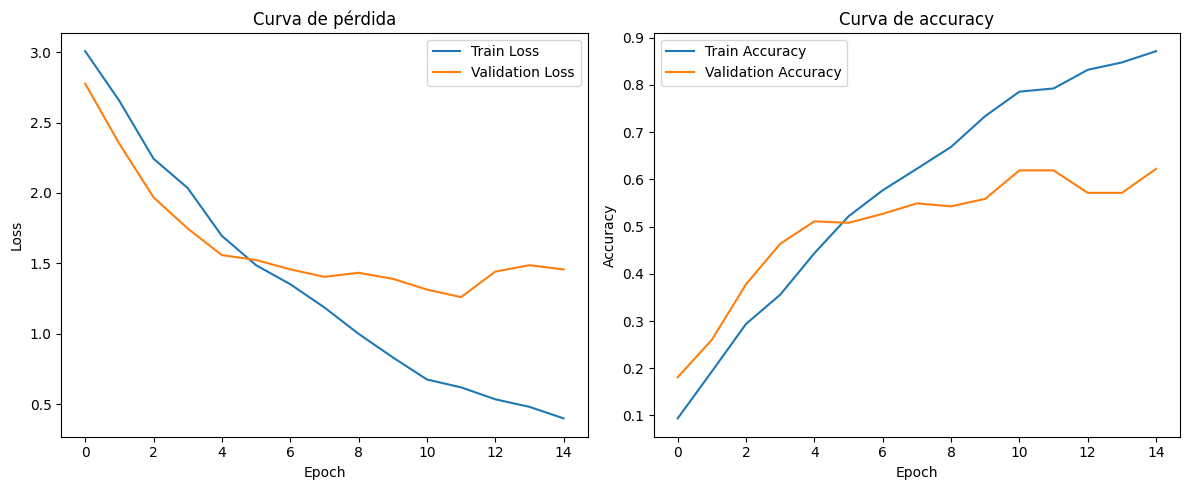

In [9]:
# =========================================================
# GRÁFICAS DE ENTRENAMIENTO
# =========================================================

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de pérdida")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curva de accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()


In [10]:
# =========================================================
# EVALUACIÓN EN TEST
# =========================================================

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())



In [11]:
# =========================================================
# MÉTRICAS
# =========================================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\n==============================")
print("RESULTADOS EN TEST")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nReporte de clasificación:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


RESULTADOS EN TEST
Accuracy : 0.6254
Precision: 0.6387
Recall   : 0.6254
F1-Score : 0.6163

Reporte de clasificación:

                   precision    recall  f1-score   support

     agricultural       0.76      0.68      0.72        19
         airplane       0.75      0.55      0.63        11
  baseballdiamond       0.92      0.73      0.81        15
            beach       1.00      1.00      1.00        16
        buildings       0.43      0.50      0.46        12
        chaparral       0.94      0.89      0.91        18
 denseresidential       0.27      0.40      0.32        10
           forest       0.94      0.88      0.91        17
          freeway       0.93      0.81      0.87        16
       golfcourse       0.40      0.55      0.46        11
           harbor       0.68      0.93      0.79        14
     intersection       0.47      0.50      0.48        14
mediumresidential       0.41      0.43      0.42        21
   mobilehomepark       0.56      0.31      0.40     

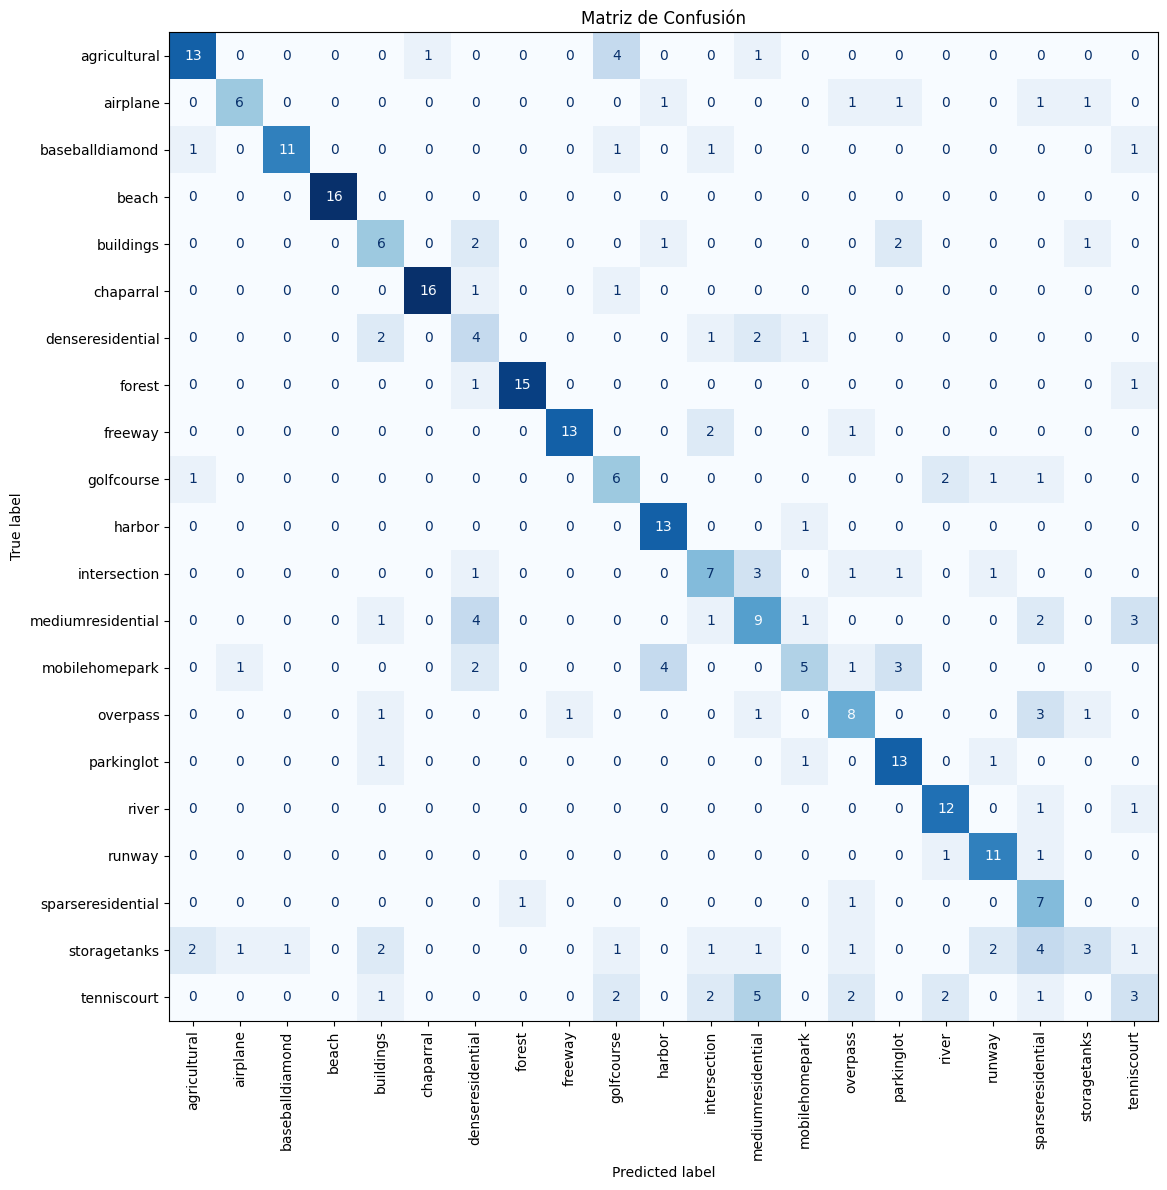

In [12]:
# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("Matriz de Confusión")
plt.tight_layout()

plt.savefig("confusion_matrix.png")

plt.show()


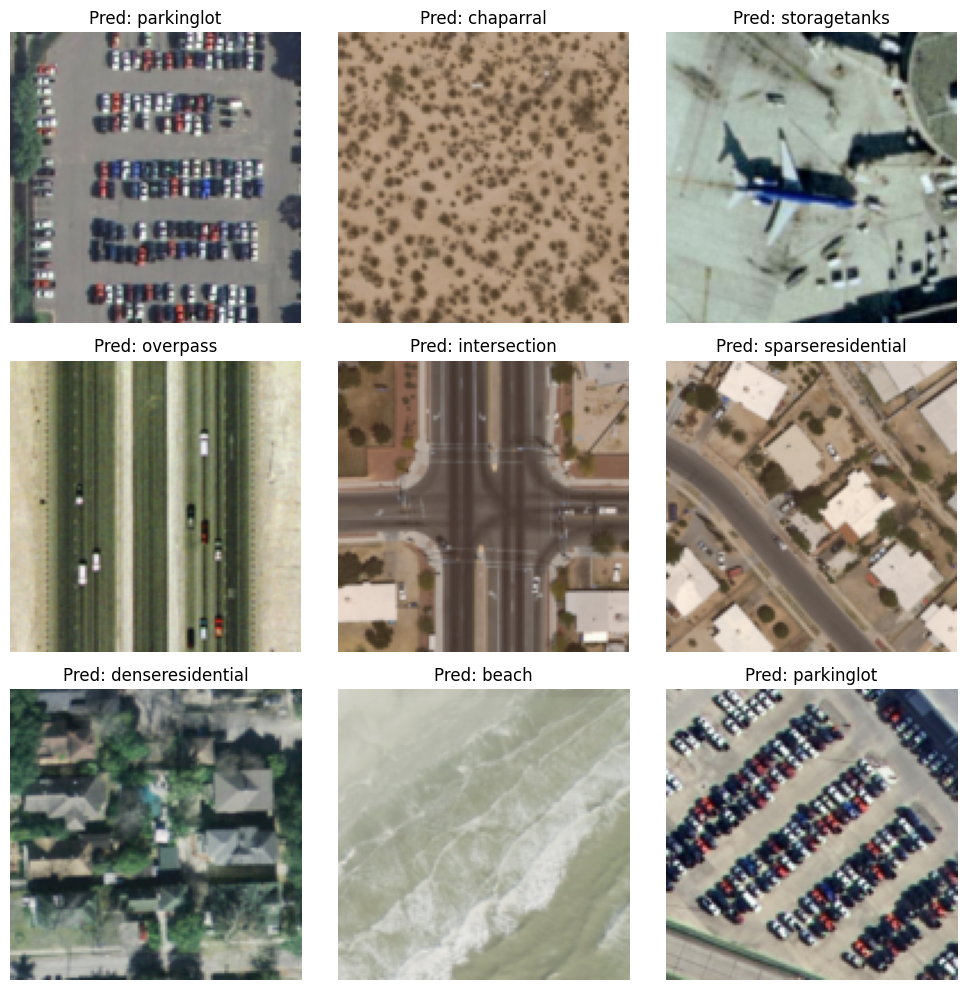


Imágenes generadas:
- training_curves.png
- confusion_matrix.png
- predictions.png


In [13]:
# =========================================================
# PREDICCIÓN DE EJEMPLOS
# =========================================================

def show_predictions(model, loader, class_names, num_images=9):

    model.eval()

    images_so_far = 0

    fig = plt.figure(figsize=(10, 10))

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            for j in range(images.size()[0]):

                images_so_far += 1

                ax = plt.subplot(3, 3, images_so_far)

                ax.axis("off")

                ax.set_title(
                    f"Pred: {class_names[preds[j]]}"
                )

                img = images.cpu().data[j].numpy().transpose((1, 2, 0))

                plt.imshow(img)

                if images_so_far == num_images:

                    plt.tight_layout()

                    plt.savefig("predictions.png")

                    plt.show()

                    return


show_predictions(model, test_loader, class_names)

print("\nImágenes generadas:")
print("- training_curves.png")
print("- confusion_matrix.png")
print("- predictions.png")

#Parte II. Modelo pre-entrenado

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import numpy as np

In [4]:
DATASET_PATH = "Images"

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [5]:
train_transforms = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(224),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
dataset = datasets.ImageFolder(
    root="/content/datos_curso/Images",
    transform=train_transforms
)

class_names = dataset.classes

print("Classes:", class_names)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

val_dataset.dataset.transform = test_transforms
test_dataset.dataset.transform = test_transforms

Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [8]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


In [9]:
for param in model.parameters():
    param.requires_grad = False

In [10]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(class_names)
)

model = model.to(DEVICE)

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=LEARNING_RATE
)

In [12]:
train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # TRAIN
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    print("Train Loss:", train_loss)

    # VALIDATION
    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

    val_loss = running_loss / len(val_loader)

    val_losses.append(val_loss)

    print("Validation Loss:", val_loss)


Epoch 1/10
Train Loss: 2.3390252279198687
Validation Loss: 1.499489140510559

Epoch 2/10
Train Loss: 1.162092642939609
Validation Loss: 0.8571686446666718

Epoch 3/10
Train Loss: 0.7507011508164199
Validation Loss: 0.6294554233551025

Epoch 4/10
Train Loss: 0.5536319853171058
Validation Loss: 0.5115003317594529

Epoch 5/10
Train Loss: 0.4604052693947502
Validation Loss: 0.4505141466856003

Epoch 6/10
Train Loss: 0.38781420076670853
Validation Loss: 0.3957730412483215

Epoch 7/10
Train Loss: 0.3302123886735543
Validation Loss: 0.360742112994194

Epoch 8/10
Train Loss: 0.28702900331953296
Validation Loss: 0.34052188992500304

Epoch 9/10
Train Loss: 0.257067754054847
Validation Loss: 0.3285824194550514

Epoch 10/10
Train Loss: 0.24761811805808026
Validation Loss: 0.3233816221356392


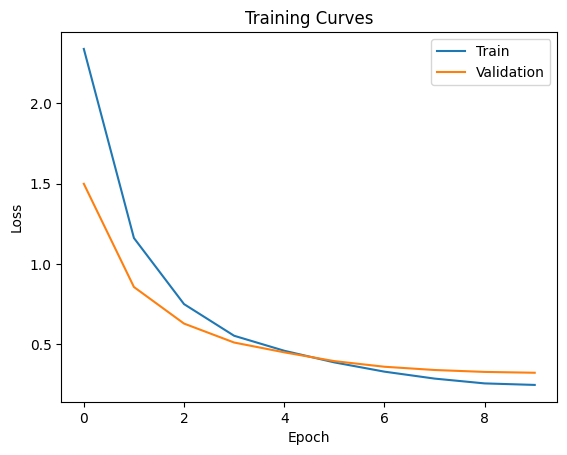

In [13]:
plt.plot(train_losses, label="Train")

plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Curves")

plt.legend()

plt.show()

In [14]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())

        y_pred.extend(preds.cpu().numpy())

In [15]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


Accuracy: 0.8698412698412699

Classification Report:

                   precision    recall  f1-score   support

     agricultural       1.00      1.00      1.00        12
         airplane       0.95      0.95      0.95        19
  baseballdiamond       0.87      0.93      0.90        14
            beach       1.00      0.93      0.97        15
        buildings       0.82      0.78      0.80        18
        chaparral       1.00      1.00      1.00        17
 denseresidential       0.71      0.62      0.67        16
           forest       0.94      1.00      0.97        16
          freeway       0.87      1.00      0.93        13
       golfcourse       0.86      0.80      0.83        15
           harbor       1.00      0.94      0.97        17
     intersection       0.80      0.83      0.82        24
mediumresidential       0.70      0.88      0.78        16
   mobilehomepark       0.91      0.91      0.91        11
         overpass       1.00      0.78      0.88         9


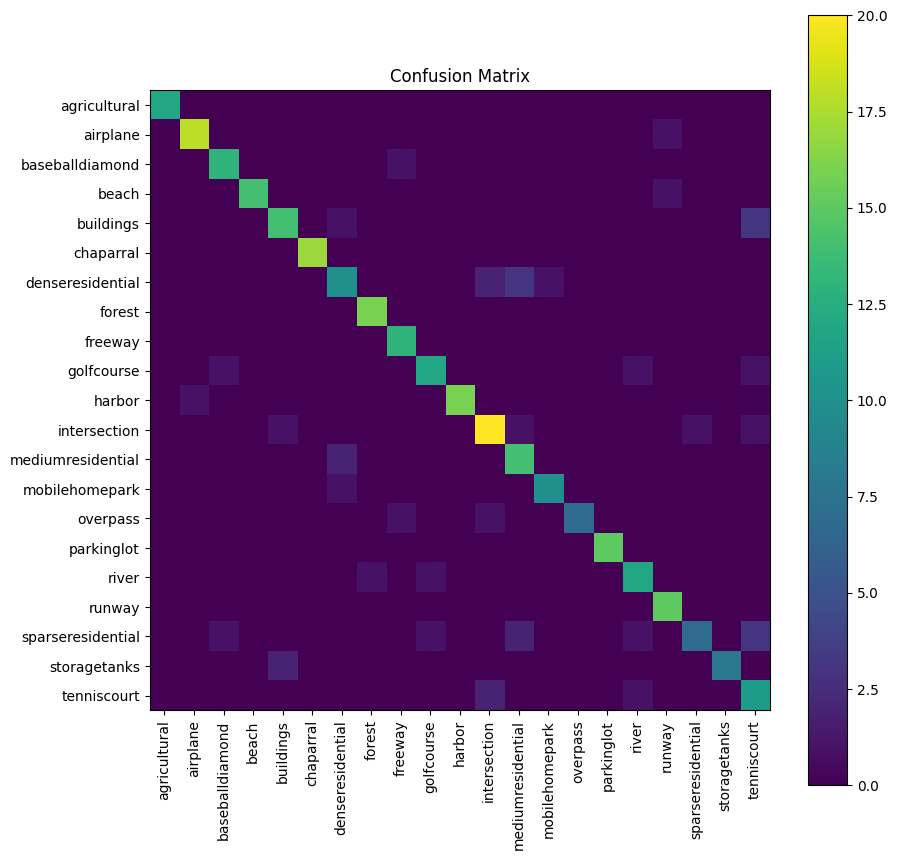

In [16]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,10))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.show()

### Librerías

Verificación versión de TensorFlow

In [ ]:
import matplotlib.pyplot as plt
import random
import seaborn as sns
import os
from PIL import Image
from tensorflow.keras.models import Sequential
import tensorflow as tf
##########################################################################
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
##########################################################################
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import kagglehub
from sklearn.metrics import classification_report  #Cálculo de las métricas

Los imágenes a clasificar son tomadas de:

Julien de la Bruère-Terreault, conjunto de datos "Rock-Paper-Scissors Images", disponible bajo la licencia CC BY-SA 4.0 (https://creativecommons.org/licenses/by-sa/4.0/) en https://www.kaggle.com/datasets/drgfreeman/rockpaperscissors

In [ ]:
# Clonar repositorio
!git clone https://github.com/ednavivianasegura/ERAP_CursoPython/
os.chdir("/content/ERAP_CursoPython/Modulo2_Fundamentos_AI")



Cloning into 'ERAP_CursoPython'...
remote: Enumerating objects: 1080, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 1080 (delta 172), reused 90 (delta 90), pack-reused 885 (from 3)
Receiving objects: 100% (1080/1080), 64.24 MiB | 12.75 MiB/s, done.
Resolving deltas: 100% (568/568), done.


In [ ]:
# Descarga el dataset "rockpaperscissors" del usuario "drgfreeman" usando Kaggle Hub
# Retorna la ruta donde se guardó el dataset descargado
path = kagglehub.dataset_download("drgfreeman/rockpaperscissors")

# Lista todos los archivos y directorios contenidos en la ruta de descarga
# os.listdir() devuelve una lista con los nombres de las entradas en el directorio
contenido = os.listdir(path)

# Notas importantes:
# 1. kagglehub.dataset_download() descarga el dataset en un formato específico de Kaggle
# 2. El dataset puede venir en diferentes estructuras:
#    - Como directorio con subdirectorios (rock/, paper/, scissors/)
#    - Como archivo comprimido (dataset.zip)
# 3. Si os.listdir() falla, puede ser porque:
#    - La descarga no se completó correctamente
#    - El path retornado no es un directorio directamente accesible
#    - Se necesitan permisos adicionales



In [ ]:
# Imprime el número de archivos en el directorio 'rock'
print(len(os.listdir(path + "/" + "rock")))  # Muestra cuántas imágenes de 'rock' hay disponibles

# Imprime el número de archivos en el directorio 'paper'
print(len(os.listdir(path + "/" + "paper")))  # Muestra cuántas imágenes de 'paper' hay disponibles

# Lista TODOS los archivos en el directorio 'scissors' (puede ser mucha salida)
print(os.listdir(path + "/" + "scissors"))  # Muestra los nombres de todos los archivos de 'scissors'

726
712
['TfQG2fJYyDv8Ic8P.png', 'EesxTpYzhZoMVlH8.png', '8Gew5erdZ7A4K3gI.png', 'RydyYWgvhLQPwEaw.png', '256MrhkDete6aQhP.png', 'o1cPo5Z2YLfTz2vJ.png', 'jWUoY57nkFKUUdD5.png', 'cDveaur4dR2ZCCo8.png', 'JSDICtLrQIEXhPy5.png', 'eqJEQe8W9FP4TOck.png', 'j1EfA5DclfCJdzLb.png', 'FoYWUBXBw6qO7y0f.png', 'cPuxKnJCdcTotM5k.png', '7vtC68OSHd1FZJvN.png', 'OA0s5AsfJEm96cxd.png', 'aMAVOdimraDSK6P1.png', 'gzRmdTIFRzV34Vjl.png', 'jMVjrTQfvJ0xLTOt.png', 'zdo3LHesq3aHmu1f.png', 'lhD4U5er2UL6nfAH.png', '8Q1PAZsxpLf5FAo6.png', 'kC1AoCFrvaMKlTDk.png', 'NR48QMe5e1gskpA9.png', '2C9FEbBklwcVhF3W.png', 'mmLhBFvXWgD957XY.png', 'QGySPOxev60wlq1M.png', 'vMAludIRGF14FuGn.png', 'WUEe440w137BuSEE.png', 'pZ9zE5ahoKZhIZqm.png', '3n4i3lKB3nZOpDVv.png', 'bn7yju6XvU87slzH.png', '2ZPcSpOm7SEfQYwg.png', 'KSNET1XTWbrg5Rcz.png', 'oYB271o4Oo5uFHpW.png', '55yz6JI9f5DTbq9D.png', '5DdrFpDc8YbG1oCo.png', '64ktckSF0c26K6AY.png', 'oxyMOfWC1lQU6dRf.png', '5mipmm4t8RM5o0tW.png', 'wT8z7icdMJt816Ix.png', 'UPH9bl4Vrq4Gwp3K.png', 'FCsZ8x

### Cargar Imágenes del repositorio:

Se considera que las imágenes están organizadas por categoría, almacenadas en directorios separados llamados *rock*, *paper* y *scissors*. Dentro de cada uno, los archivos de imagen están nombrados secuencialmente desde 0.png hasta 699.png, representando su número correspondiente.


In [ ]:
# Descripción de clases y su identificador
descripcion = ("paper", "rock", "scissors")
clases = {"paper": 0, "rock": 1, "scissors": 2}

# Número de imágenes de cada clase a considerar (máximo 700)
num_img_clase = 700

# Porcentajes de división
train_ratio = 0.7
test_ratio = 0.3

# Calcular número de imágenes para entrenamiento y prueba
num_entrena = round(num_img_clase * train_ratio)
num_prueba  = round(num_img_clase * test_ratio)

# Inicializar arrays para almacenar los datos
imagenes_entrena = np.empty((num_entrena * len(clases), 200, 300, 3), dtype="uint8")
clases_entrena   = np.empty(num_entrena * len(clases), dtype="uint8")

imagenes_prueba = np.empty((num_prueba * len(clases), 200, 300, 3), dtype="uint8")
clases_prueba   = np.empty(num_prueba * len(clases), dtype="uint8")

# Para cada clase, seleccionar 700 imágenes aleatorias y dividirlas en train/test
for clase in clases:
    # Obtener lista de todos los archivos en el directorio de la clase
    archivos = os.listdir(path + "/" + clase)

    # Seleccionar aleatoriamente 700 imágenes (sin repetición)
    archivos_seleccionados = random.sample(archivos, num_img_clase)

    # Dividir en conjuntos de entrenamiento y prueba
    archivos_train = archivos_seleccionados[:num_entrena]
    archivos_test = archivos_seleccionados[num_entrena:num_img_clase]

    # Cargar imágenes de entrenamiento
    for i, archivo in enumerate(archivos_train):
        imagen = Image.open(os.path.join(path, clase, archivo))
        indice = i + clases[clase] * num_entrena
        imagenes_entrena[indice] = np.array(imagen)
        clases_entrena[indice] = clases[clase]

    # Cargar imágenes de prueba
    for i, archivo in enumerate(archivos_test):
        imagen = Image.open(os.path.join(path, clase, archivo))
        indice = i + clases[clase] * num_prueba
        imagenes_prueba[indice] = np.array(imagen)
        clases_prueba[indice] = clases[clase]

# Verificación
print(f"Total imágenes entrenamiento: {len(imagenes_entrena)}")
print(f"Total imágenes prueba: {len(imagenes_prueba)}")
print("¡Datos cargados exitosamente!")

Total imágenes entrenamiento: 1470
Total imágenes prueba: 630
¡Datos cargados exitosamente!


# Visualización de imágenes aleatorias

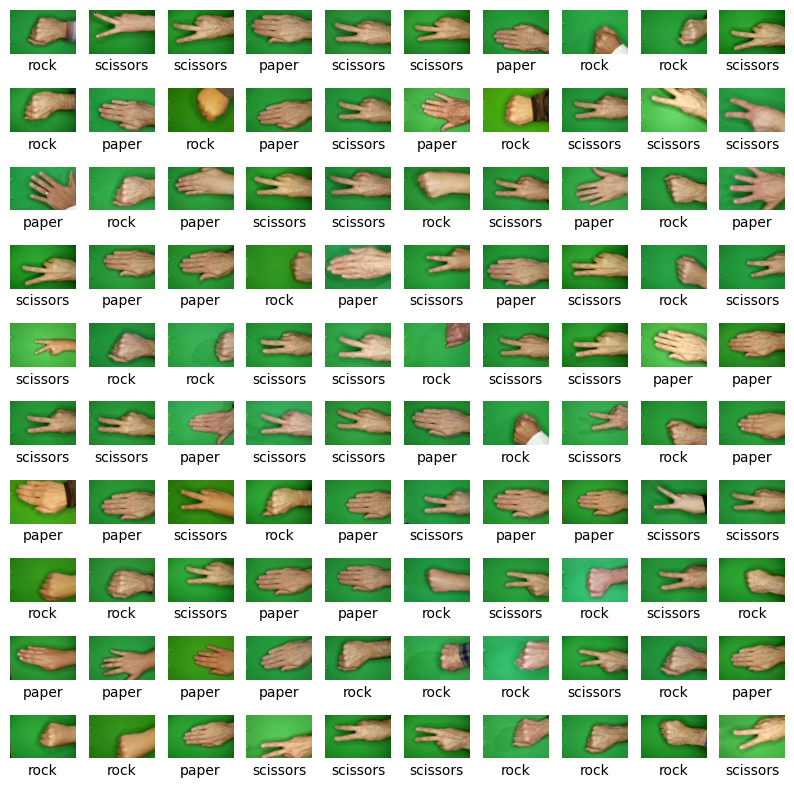

In [ ]:
# Crear una figura de matplotlib con tamaño 10x10 pulgadas
plt.figure(figsize=(10, 10))

# Mostrar 100 imágenes en una cuadrícula de 10x10
for i in range(100):
    # Crear subplot en posición i+1 (comienza en 1, no en 0)
    plt.subplot(10, 10, i + 1)

    # Seleccionar un índice aleatorio dentro del rango de imágenes de entrenamiento
    indice = random.randint(0, num_entrena*len(clases) - 1)

    # Mostrar la imagen correspondiente al índice seleccionado
    # Se usa cmap="gray" para mostrar en escala de grises (aunque las imágenes son RGB)
    plt.imshow(imagenes_entrena[indice], cmap="gray")

    # Añadir etiqueta (clase) como texto en la parte inferior
    plt.xlabel(descripcion[clases_entrena[indice]])

    # Configuraciones de estilo para mejorar la visualización:
    plt.grid(False)    # Desactivar cuadrícula
    plt.box(False)     # Desactivar borde alrededor de la imagen
    plt.xticks([])     # Eliminar marcas del eje X
    plt.yticks([])     # Eliminar marcas del eje Y

# Mostrar la figura completa con todas las sub-imágenes
plt.show()

## Visualización de una sola imagen en tamaño grande

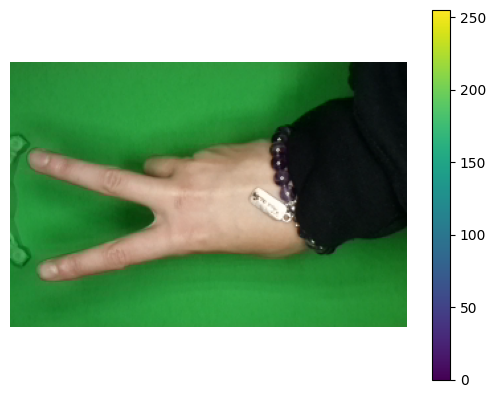

In [ ]:
num_aleatorio = random.randint(0, 700)
# Crear una nueva figura de matplotlib (tamaño por defecto)
plt.figure()

# Mostrar la imagen de prueba número aleatorio del conjunto de datos
plt.imshow(imagenes_prueba[num_aleatorio])  # Muestra la imagen con mapeo de colores automático

# Añadir una barra de color (colorbar) que indica la escala de valores de píxeles
plt.colorbar()  # Útil para entender el rango de valores de intensidad en la imagen

# Configuraciones de estilo para una visualización más limpia:
plt.grid(False)    # Desactivar la cuadrícula (repetido por seguridad)
plt.box(False)     # Desactivar el borde alrededor de la imagen
plt.grid(False)    # Desactivar la cuadrícula nuevamente (redundante pero inofensivo)
plt.xticks([])     # Eliminar las marcas y etiquetas del eje X
plt.yticks([])     # Eliminar las marcas y etiquetas del eje Y

# Mostrar la figura con la imagen y la barra de color
plt.show()

In [ ]:
### Escalar los píxeles de las imágenes del rango [0, 255] al rango [0, 1]
imagenes_entrena = imagenes_entrena / 255
imagenes_prueba = imagenes_prueba / 255

# Modelo CNN para Clasificación de Imágenes

In [ ]:
# Definición del modelo secuencial (capas apiladas linealmente)

model = Sequential()

# Primera capa convolucional:
# - 32 filtros de 3x3 píxeles
# - Función de activación ReLU (Rectified Linear Unit)
# - Input shape: 200 (alto) x 300 (ancho) x 3 canales (RGB)

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(200, 300, 3)))

# Capa de Max Pooling:
# - Reducción dimensional con ventana de 2x2
# - Reduce el tamaño espacial a la mitad (selecciona el valor máximo en cada ventana)

model.add(MaxPooling2D((2, 2)))

# Segunda capa convolucional:
# - 64 filtros de 3x3 píxeles
# - Función de activación ReLU

model.add(Conv2D(64, (3, 3), activation='relu'))

# Segunda capa de Max Pooling:
# - Nueva reducción dimensional 2x2

model.add(MaxPooling2D((2, 2)))

# Capa Flatten:
# - "Aplana" los mapas de características 2D a un vector 1D
# - Prepara los datos para las capas densas (fully connected)

model.add(Flatten())

# Capa Densa (fully connected):
# - 64 neuronas con activación ReLU
# - Capa intermedia para aprendizaje de características complejas

model.add(Dense(64, activation="relu"))

# Capa Softmax:

model.add(Dense(3, activation="softmax"))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Cofigurarción del Modelo para Entrenamiento

In [ ]:
# Optimizador: Descenso de Gradiente Estocástico (SGD)
# - Algoritmo de optimización básico que actualiza los pesos en dirección opuesta al gradiente
# Métrica a monitorear: Precisión (Accuracy)
# - Porcentaje de predicciones correctas sobre el total
# - Útil para problemas balanceados como rock-paper-scissors
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 298, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 149, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 147, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 224256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    14,352,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,372,035 (54.82 MB)

 Trainable params: 14,372,035 (54.82 MB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento de la CNN

In [ ]:
# Entrena la red neuronal con las imágenes y clases del conjunto de entrenamiento.
# El proceso se repite durante 10 épocas, es decir, el modelo verá todo el conjunto de datos 10 veces.
history = model.fit(imagenes_entrena, clases_entrena, epochs=10)


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.3920 - loss: 1.0879
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step - accuracy: 0.6577 - loss: 0.8477
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.7759 - loss: 0.6103
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.8214 - loss: 0.4886
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.8786 - loss: 0.3614
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9095 - loss: 0.2837
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - accuracy: 0.9257 - loss: 0.2467
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.9370 - loss: 0.1921
Epoch 9/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.9399 - loss: 0.1819
Epoch 10/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.9493 - loss: 0.1550


# Evaluación del modelo

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 905ms/step - accuracy: 0.8892 - loss: 0.2477
Pérdida (Loss) en el conjunto de prueba: 0.2041
Exactitud (Accuracy) = aciertos_prueba / imagenes_de_prueba: 0.9238095283508301
Exactitud (Accuracy) en el conjunto de prueba: 92.38%


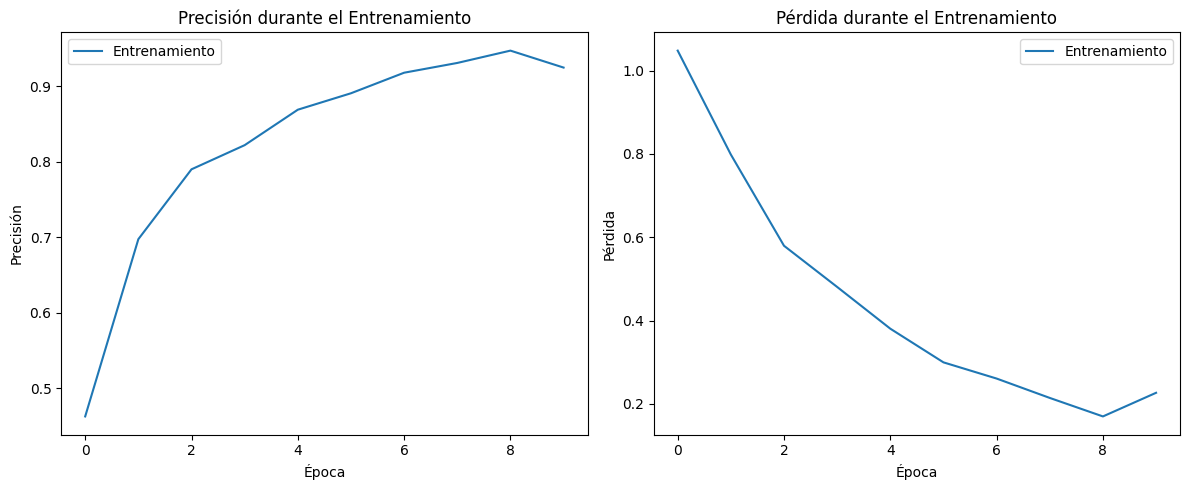

In [ ]:
# Evalúa el rendimiento del modelo sobre el conjunto de prueba (imágenes y etiquetas reales)
# Retorna la pérdida (loss) y la exactitud (accuracy)
loss, acc  = model.evaluate(imagenes_prueba, clases_prueba)

# Imprime la pérdida obtenida en el conjunto de prueba
print(f"Pérdida (Loss) en el conjunto de prueba: {loss:.4f}")

# Imprime la exactitud obtenida, que representa el porcentaje de imágenes clasificadas correctamente
print("Exactitud (Accuracy) = aciertos_prueba / imagenes_de_prueba:", acc)

# Imprime la exactitud como porcentaje con dos decimales
print(f"Exactitud (Accuracy) en el conjunto de prueba: {acc * 100:.2f}%")

# Gráficas de precisión y pérdida
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.title('Precisión durante el Entrenamiento')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.title('Pérdida durante el Entrenamiento')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()


# Clasificación de las imágenes del conjunto de entrenamiento con la CNN entrenada

In [ ]:
# Genera predicciones del modelo para las imágenes del conjunto de pruentrenamiento
# El resultado será un array con las probabilidades asignadas a cada clase para cada imagen
predicciones_train = model.predict(imagenes_entrena)

46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 910ms/step


In [ ]:
# Obtener las clases predichas (índice con mayor probabilidad para cada imagen)
clase_predicha_train = np.argmax(predicciones_train, axis=1)


Matriz de Confusión conjunto entrenamiento:
 [[437  13  40]
 [  5 483   2]
 [ 14   3 473]]


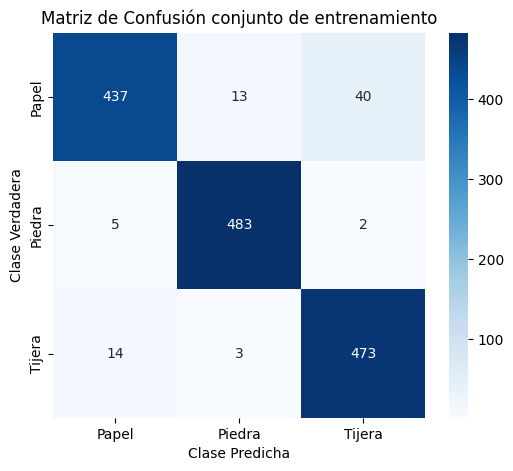


Reporte de clasificación:
              precision    recall  f1-score   support

       Papel       0.96      0.89      0.92       490
      Piedra       0.97      0.99      0.98       490
      Tijera       0.92      0.97      0.94       490

    accuracy                           0.95      1470
   macro avg       0.95      0.95      0.95      1470
weighted avg       0.95      0.95      0.95      1470



In [ ]:
# Calcula la matriz de confusión
matriz_train = confusion_matrix(clases_entrena, clase_predicha_train)

# Imprime la matriz de confusión
print("Matriz de Confusión conjunto entrenamiento:\n", matriz_train)

# Define etiquetas de clase
etiquetas = ['Papel', 'Piedra', 'Tijera']

# Dibuja el mapa de calor
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_train, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.title("Matriz de Confusión conjunto de entrenamiento")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Verdadera")
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(clases_entrena, clase_predicha_train, target_names=etiquetas))

# Clasificación de las Imágenes del conjunto de prueba con la CNN entrenada

In [ ]:
# Genera predicciones del modelo para las imágenes del conjunto de prueba
# El resultado será un array con las probabilidades asignadas a cada clase para cada imagen
predicciones = model.predict(imagenes_prueba)


20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 928ms/step


# Salida de la CNN para cada imagen del conjunto de prueba

In [ ]:
# Obtener las clases predichas (índice con mayor probabilidad para cada imagen)
clase_predicha = np.argmax(predicciones, axis=1)


# Resultado de la evaluación: matriz de confusión:

Matriz de Confusión conjunto entrenamiento:
 [[177   3  30]
 [  1 205   4]
 [  8   2 200]]


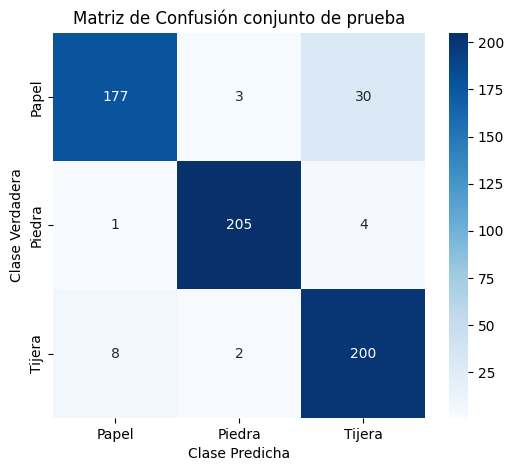

In [ ]:
# Asignación de etiquetas numéricas para cada clase: papel = 0, piedra = 1, tijera = 2
# Genera la matriz de confusión comparando etiquetas reales con predichas
matriz_test = confusion_matrix(clases_prueba, clase_predicha)

# Imprime la matriz de confusión
# Imprime la matriz de confusión
print("Matriz de Confusión conjunto entrenamiento:\n", matriz_test)

# Define etiquetas de clase
etiquetas = ['Papel', 'Piedra', 'Tijera']

# Dibuja el mapa de calor
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.title("Matriz de Confusión conjunto de prueba")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Verdadera")
plt.show()

# Actividad

Dataset: CIFAR-10
CIFAR-10 es un conjunto de datos clásico que contiene 60,000 imágenes a color de 32x32 píxeles, divididas en 10 clases (aviones, automóviles, pájaros, gatos, ciervos, perros, ranas, caballos, barcos y camiones). Cada clase tiene 6,000 imágenes.


Realizar la calsificación de las 10 clases utilizando CNN

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


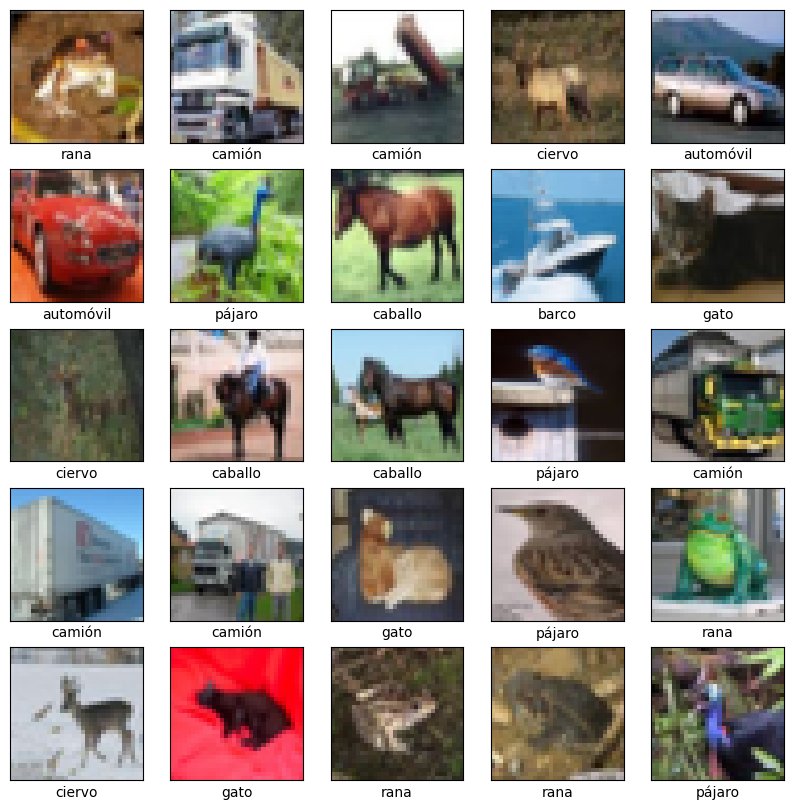

In [ ]:
# Cargar el dataset CIFAR-10 de Keras
# train_images: 50000 imágenes de entrenamiento (32x32 píxeles, 3 canales RGB)
# train_labels: 50000 etiquetas (0-9) para las imágenes de entrenamiento
# test_images: 10000 imágenes de prueba
# test_labels: 10000 etiquetas para las imágenes de prueba
(imagenes_entre, clases_entre), (imagenes_pru, clases_pru) = tf.keras.datasets.cifar10.load_data()

# Normalización: escalar los valores de píxeles al rango [0, 1] dividiendo por 255
# Esto ayuda a que la red neuronal converja más rápido
imagenes_entre, imagenes_pru = imagenes_entre / 255.0, imagenes_pru / 255.0

# Nombres descriptivos para cada clase (índices 0-9)
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Visualización de 25 imágenes del conjunto de entrenamiento con sus etiquetas
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)  # Crear una cuadrícula de 5x5 subplots
    plt.xticks([])  # Eliminar marcas en eje X
    plt.yticks([])  # Eliminar marcas en eje Y
    plt.grid(False)  # Desactivar grid
    plt.imshow(imagenes_entre[i])  # Mostrar imagen
    # Mostrar etiqueta como texto (accediendo al primer elemento de train_labels[i])
    plt.xlabel(class_names[clases_entre[i][0]])
plt.show()


In [ ]:
# Diccionario que mapea índices numéricos a nombres de clases

etiquetas_cifar10 = {
    0: 'avión',
    1: 'automóvil',
    2: 'pájaro',
    3: 'gato',
    4: 'ciervo',
    5: 'perro',
    6: 'rana',
    7: 'caballo',
    8: 'barco',
    9: 'camión'
}

In [ ]:
# Construcción del modelo de red neuronal convolucional (CNN)
mod_act = Sequential()
# Primera capa convolucional con 32 filtros de 3x3 y activación ReLU
mod_act.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
# Capa de Max Pooling para reducción dimensional (2x2)
mod_act.add(MaxPooling2D((2, 2)))
# Segunda capa convolucional con 64 filtros
mod_act.add(Conv2D(64, (3, 3), activation='relu'))
# Otra capa de Max Pooling
mod_act.add(MaxPooling2D((2, 2)))
# Tercera capa convolucional
mod_act.add(Conv2D(64, (3, 3), activation='relu'))
# Aplanar la salida para conectarla a capas densas
mod_act.add(Flatten())
# Capa densa (fully connected) con 64 neuronas
mod_act.add(Dense(64, activation="relu"))
# Capa de salida con 10 neuronas (una por clase)
mod_act.add(Dense(10, activation="softmax"))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compilación del modelo:
# - Optimizador: Adam (variante de SGD)
# - Función de pérdida: SparseCategoricalCrossentropy (para etiquetas enteras)
# - Métrica a monitorear: accuracy (precisión)
mod_act.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Resumen del modelo: muestra la arquitectura y número de parámetros
mod_act.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo:
# - train_images: imágenes de entrenamiento
# - train_labels: etiquetas de entrenamiento
# - epochs: 10 pasadas completas por el dataset
history_activiy=mod_act.fit(imagenes_entre, clases_entre, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 45ms/step - accuracy: 0.3468 - loss: 1.7501
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.5906 - loss: 1.1731
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.6464 - loss: 1.0103
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6808 - loss: 0.9031
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.7105 - loss: 0.8317
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 49ms/step - accuracy: 0.7287 - loss: 0.7762
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - accuracy: 0.7510 - loss: 0.7173
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 45ms/step - accuracy: 0.7675 - loss: 0.6660
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7805 - loss: 0.6299
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.7936 - loss: 0.5898


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7144 - loss: 0.8578
Pérdida (Loss) en el conjunto de prueba: 0.8556
Exactitud (Accuracy) = aciertos_prueba / imagenes_de_prueba: 0.7164000272750854
Exactitud (Accuracy) en el conjunto de prueba: 71.64%


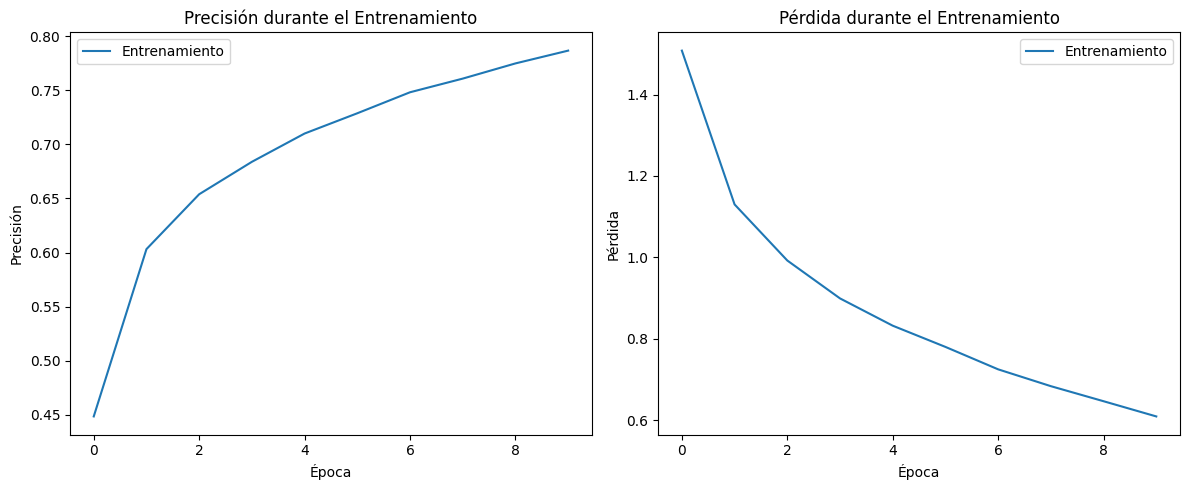

In [ ]:
# Evalúa el modelo en el conjunto de prueba
perdida, exactitud = mod_act.evaluate(imagenes_pru, clases_pru)

print(f"Pérdida (Loss) en el conjunto de prueba: {perdida:.4f}")
print("Exactitud (Accuracy) = aciertos_prueba / imagenes_de_prueba:", exactitud)
print(f"Exactitud (Accuracy) en el conjunto de prueba: {exactitud * 100:.2f}%")

# Gráficas de precisión y pérdida
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_activiy.history['accuracy'], label='Entrenamiento')
plt.title('Precisión durante el Entrenamiento')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_activiy.history['loss'], label='Entrenamiento')
plt.title('Pérdida durante el Entrenamiento')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Generar predicciones para el conjunto de prueba
# predicciones será un array de shape (10000, 10) con los logits para cada clase
predicciones_actividad = mod_act.predict(imagenes_pru)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


Matriz de Confusión conjunto entrenamiento:
 [[758  11  47  34  31   9  10  16  50  34]
 [ 18 795   9  15   3   4  22   5  25 104]
 [ 63   2 517  95 140  58  57  39  14  15]
 [ 20   4  43 629  69 100  63  36  14  22]
 [ 10   4  35  79 740  22  41  59   8   2]
 [  7   2  31 276  70 520  22  63   4   5]
 [  5   3  32  84  51  17 784  11   5   8]
 [ 15   0  19  68  79  33   6 762   2  16]
 [ 46  22  14  22  12   3   6  12 820  43]
 [ 28  47   7  20   8   5   6  22  18 839]]


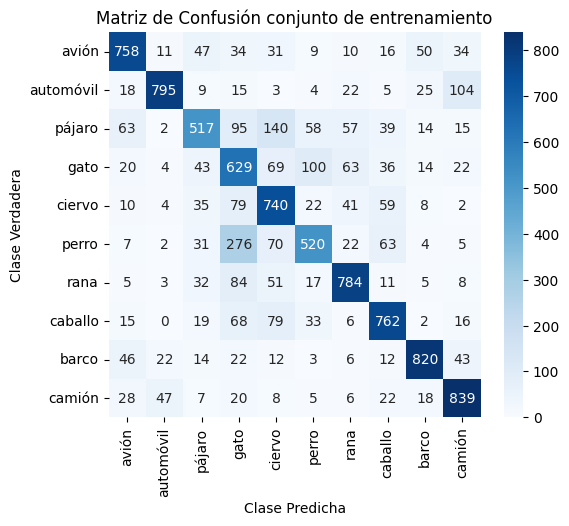


Reporte de clasificación:
              precision    recall  f1-score   support

       avión       0.78      0.76      0.77      1000
   automóvil       0.89      0.80      0.84      1000
      pájaro       0.69      0.52      0.59      1000
        gato       0.48      0.63      0.54      1000
      ciervo       0.62      0.74      0.67      1000
       perro       0.67      0.52      0.59      1000
        rana       0.77      0.78      0.78      1000
     caballo       0.74      0.76      0.75      1000
       barco       0.85      0.82      0.84      1000
      camión       0.77      0.84      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



In [ ]:
# Obtener las clases predichas (índice con mayor probabilidad para cada imagen)
clase_predicha_actividad = np.argmax(predicciones_actividad, axis=1)

# El dataset cifar10 devuelve las etiquetas (clases_pru) en forma de array bidimensional, de forma (n, 1).
# Por ejemplo:
# [[3], [0], [6], [1], [2], ...]
# flatten las convierte a el formato que espera sklearn:
# [3, 0, 6, 1, 2, ...]

clases_pru_flat = clases_pru.flatten()
# Calcula la matriz de confusión
matriz_entrenamiento = confusion_matrix(clases_pru_flat, clase_predicha_actividad)

# Imprime la matriz de confusión
print("Matriz de Confusión conjunto entrenamiento:\n", matriz_entrenamiento)

# Define etiquetas de clase
etiquetas = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Dibuja el mapa de calor
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_entrenamiento, annot=True, fmt="d", cmap="Blues",
            xticklabels=etiquetas, yticklabels=etiquetas)

plt.title("Matriz de Confusión conjunto de entrenamiento")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Verdadera")
plt.show()

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(clases_pru_flat, clase_predicha_actividad, target_names=etiquetas))
